In [1]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd 
import datetime
import scipy
import torch
import tqdm
import xarray as xr

from cartopy.feature import LAND, BORDERS
from dantro.plot.utils import ColorManager
from pyproj import Transformer

# Local imports
import include as base

In [2]:
# Style settings
from matplotlib import rcParams
from cycler import cycler
colors = {
    
    'c_darkblue': '#2F7194',
    'c_red': '#ec7070',
    'c_darkgreen': '#48675A',
    'c_lightblue': '#97c3d0',
    'c_lightgreen': '#AFD8BC',
    'c_lightbrown': '#C6BFA2',
    'c_orange': '#EC9F7E',
    'c_yellow': '#F5DDA9',
    'c_darkgrey': '#3D4244',
    'c_pink': '#F8A6A6',
    'c_purple': '#A07CB0',
    'c_lightgrey': '#AFC1B9',
}
rcParams['axes.prop_cycle'] = cycler(color=list(colors.values()))
fs=9
rcParams.update(**{
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb} \usepackage{amsmath}",
    "font.size": fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    # "figure.dpi": 300
})
%matplotlib inline

---
# Load datasets
---

In [3]:
# Load the UN net migration data
UN_data = xr.load_dataset("../../../data/Migration/UN_data.nc")

# Five-year bilateral flow estimates
five_year_estimates = xr.open_dataset("../../../data/Migration/bilateral_estimates.nc")

# Load the flow estimates from the stock data interpolation
stock_data = xr.load_dataarray("../../../data/Migration/UN_stock_data_ext.nc")

# Conversion table for ISO3 codes
iso3_to_name = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Iso_code_lookup.csv").set_index('Alpha-3 code')['Country'].to_dict()

# Country coordinates
country_coords = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Coordinates.csv", index_col=2)
country_coords = country_coords[~country_coords.index.duplicated()]

---
# Convert to torch.tensor for training
---

In [42]:
# Convert the net migration to torch
start, end = 1990, 2021
net_migration_training_data = torch.from_numpy(
    UN_data['Net Number of Migrants (thousands)'].transpose('Year', ...).sel({'Year': range(start, end + 1)}).data * 1000
).float()
N = net_migration_training_data.shape[1]

# Convert the stock data to torch numpy and take the difference along the year axis (which is all that is required for training)
stock_training_data = torch.from_numpy(
    stock_data.transpose("Year", ...).sel({"Year": np.arange(start, end+1, 5)}).data
).float()
stock_training_data_diff = torch.diff(stock_training_data, dim=0).reshape(-1, N**2)

# Get the mask for the stock data differences
mask = ~torch.isnan(stock_training_data_diff)

---
# Setup and train the neural network
---

In [189]:
NN = base.NeuralNet(
    input_size=N,
    output_size=2*N**2,
    num_layers=5,
    nodes_per_layer=dict(default=20),
    activation_funcs=dict(default='silu', layer_specific={1: 'swish', -1: 'abs'}),
    biases=dict(default=None), 
    optimizer='Adam',
    learning_rate=0.002,
)

# Store training loss in array
loss_ts = []

In [334]:
for _ in (pbar:=tqdm.tqdm(range(10000))):
    
    epoch_loss = []
    for b in range(len(stock_training_data_diff)):
        
        # Make a prediction, of shape (t: N_Years, k: 2, i: N, j: N). k=0 represents the flow of citizens of i from i to j, k=1 represents the flow of citizens of i from j to i
        prediction = NN(net_migration_training_data[5*b:(b+1)*5]).reshape(-1, 2, N, N)
        
        # Perturb the prediction by 1%
        prediction = prediction * torch.normal(1.0, 0.03, prediction.shape)
        
        # Calculate the total predicted flow across five years (inflow minus outflow)
        predicted_stock_diff = (prediction[:, 0, :] - prediction[:, 1, :]).sum(dim=0).reshape(N**2)
        
        # Calculate the predicted net migration
        predicted_net_migration = ((prediction.transpose(-2, -1)[:, 0, :] + prediction[:, 1, :]).sum(dim=-1) - (prediction[:, 0, :] + prediction.transpose(-2, -1)[:, 1, :]).sum(dim=-1))
        
        # Loss = loss on stock data + loss on net migration + trace
        loss = torch.nn.functional.mse_loss(predicted_stock_diff[mask[b]], stock_training_data_diff[b][mask[b]]) + torch.nn.functional.mse_loss(predicted_net_migration, net_migration_training_data[5*b:(b+1)*5]) + torch.diagonal(prediction.sum(dim=1), dim1=-2, dim2=-1).sum()
        
        loss.backward()
        NN.optimizer.step()
        NN.optimizer.zero_grad()
        
        epoch_loss.append(loss.clone().detach().numpy())
    
    # 2020 and 2021 not covered by stock -- learn seperately
    prediction = NN(net_migration_training_data[-2:]).reshape(-1, 2, N, N)

    # Perturb the prediction by 1%
    prediction = prediction * torch.normal(1.0, 0.03, prediction.shape)
    
    # Calculate the predicted net migration
    predicted_net_migration = ((prediction.transpose(-2, -1)[:, 0, :] + prediction[:, 1, :]).sum(dim=-1) - (prediction[:, 0, :] + prediction.transpose(-2, -1)[:, 1, :]).sum(dim=-1))

    # Loss = loss on stock data + loss on net migration + trace
    loss = torch.nn.functional.mse_loss(predicted_net_migration, net_migration_training_data[-2:]) + torch.diagonal(prediction.sum(dim=1), dim1=-2, dim2=-1).sum()

    loss.backward()
    NN.optimizer.step()
    NN.optimizer.zero_grad()
    
    epoch_loss.append(loss.clone().detach().numpy())
    
    loss_ts.append(np.mean(epoch_loss))
    pbar.set_description(f"Loss: {loss_ts[-1]}")

Loss: 189785072.0:   6%|▌         | 603/10000 [01:09<18:05,  8.66it/s]


KeyboardInterrupt: 

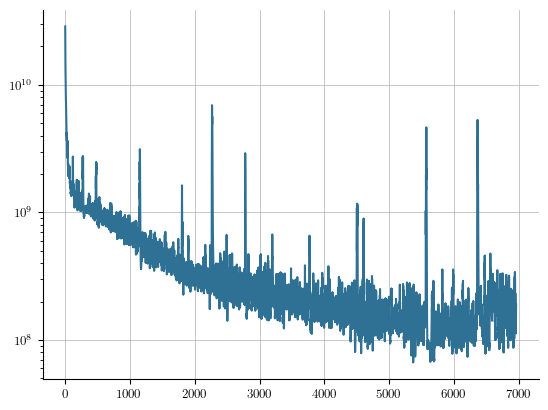

In [335]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(loss_ts)), loss_ts)
ax.set_yscale('log')

In [336]:
predictions = NN(net_migration_training_data).reshape(-1, 2, N, N).detach()
flows = predictions[:, 0, :] + predictions.transpose(-2, -1)[:, 1, :]
predictions = xr.DataArray(
    data=NN(net_migration_training_data).reshape(-1, 2, N, N).detach(),
    dims=["Year", "Direction", "Citizen ISO", "Partner ISO"],
    coords={"Year": range(start, end + 1), "Direction": ["Out", "In"], "Citizen ISO": UN_data.coords["Country ISO"].data, 
            "Partner ISO": UN_data.coords["Country ISO"].data}
)
predicted_net_migration = xr.DataArray(
    data=flows.transpose(-2, -1).sum(dim=2) - flows.sum(dim=2),
    dims=["Year", "Country ISO"],
    coords={"Year": range(start, end + 1), "Country ISO": UN_data.coords["Country ISO"].data}
)
flows = xr.DataArray(
    data=flows, 
    dims=["Year", "Origin ISO", "Destination ISO"], 
    coords={"Year": range(start, end + 1), "Origin ISO": UN_data.coords["Country ISO"].data, "Destination ISO": UN_data.coords["Country ISO"].data}
)

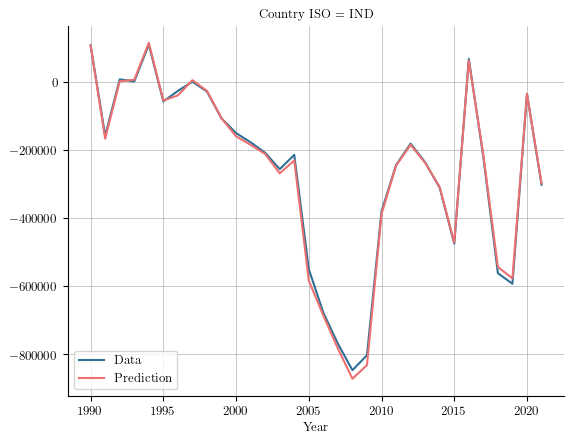

In [337]:
fig, ax = plt.subplots()
c="IND"
(UN_data['Net Number of Migrants (thousands)'].transpose('Year', ...).sel({'Year': range(start, end + 1)}) * 1000).sel({"Country ISO": c}).plot(ax=ax, label="Data")
predicted_net_migration.sel({"Country ISO": c}).plot(ax=ax, label="Prediction")
ax.legend()

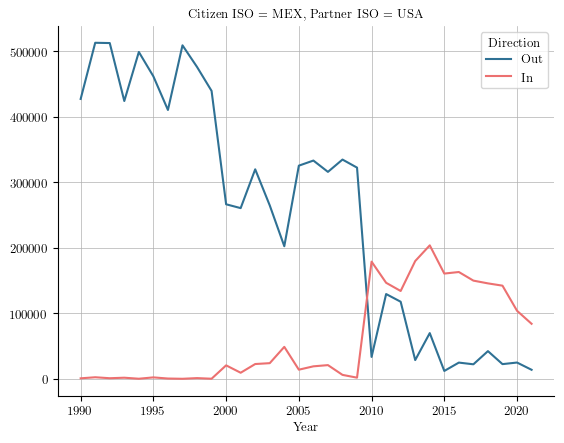

In [338]:
fig, ax = plt.subplots()
predictions.sel({"Citizen ISO": "MEX", "Partner ISO": "USA"}).plot(ax=ax, hue="Direction")
# (predictions.sel({"Citizen ISO": "IND", "Partner ISO": "GBR", "Direction": "In"}) - predictions.sel({"Citizen ISO": "IND", "Partner ISO": "GBR", "Direction": "Out"})).plot(ax=ax)

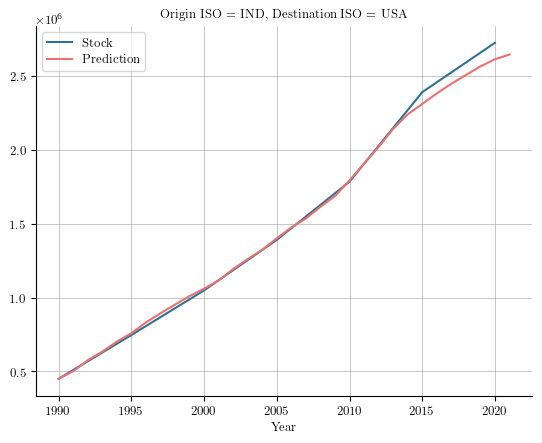

In [339]:
fig, ax = plt.subplots()
org, dest = "IND", "USA"
stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label="Stock")

stock = [stock_data.sel({"Year": start, "Origin ISO": org, "Destination ISO": dest}).data]
for y in predictions.coords["Year"].data[1:]:
    stock.append(
        stock[-1] + predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "Out", "Year": y}, drop=True) - predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "In", "Year": y}, drop=True)
    )
ax.plot(predictions.coords["Year"].data, stock, label="Prediction")
ax.legend()

In [340]:
pred_five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    pred_five_year_estimates.append(
        flows.sel({"Year": range(y, y+5)}).sum("Year")
    )
pred_five_year_estimates = xr.concat(pred_five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

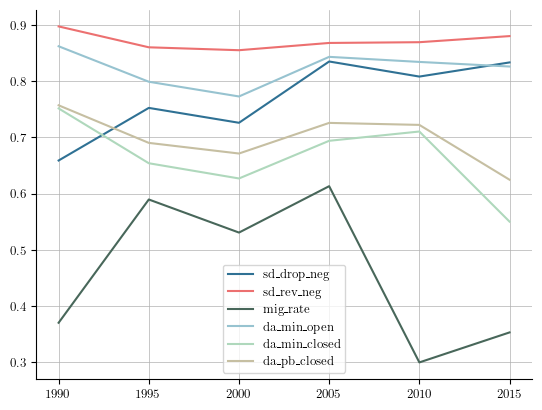

In [341]:
common_countries  = np.intersect1d(five_year_estimates.coords["Origin ISO"], pred_five_year_estimates.coords["Origin ISO"])
fig, ax = plt.subplots()
for var in list(five_year_estimates.data_vars):
    r_coeffs = []
    for year in five_year_estimates.coords["Year0"]:
        x = pred_five_year_estimates.sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        y = five_year_estimates[var].sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        msk = np.where(~np.isnan(y))
        r_coeffs.append(scipy.stats.pearsonr(x[msk], y[msk]).statistic)
    ax.plot(five_year_estimates.coords["Year0"], r_coeffs, label=var)
ax.legend()

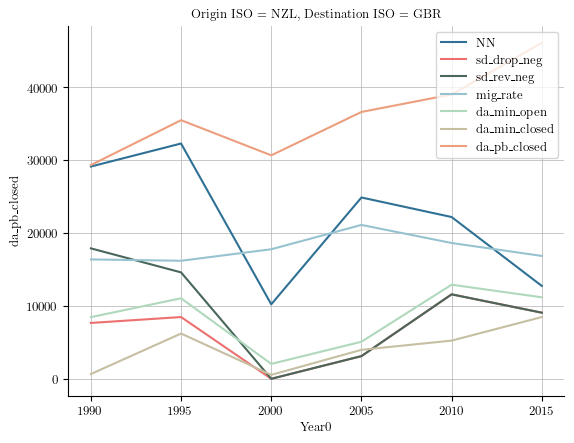

In [342]:
fig, ax = plt.subplots()
org, dest = "NZL", "GBR"
pred_five_year_estimates.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label='NN')
for var in five_year_estimates.data_vars:
    five_year_estimates[var].sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label=var)
ax.legend()

In [4]:
extended_flow = xr.open_dataset("/Users/thomasgaskin/UN_migration_data/bilateral_flows_stats.nc")
UN_net_migration = xr.open_dataarray("../../../data/Migration/UN_net_migration.nc")
flow_table = xr.Dataset(dict(
    mean = extended_flow["mean"].sel({"Direction": "Out"}) + extended_flow["mean"].sel({"Direction": "In"}).data.transpose(0, 2, 1),
    std = np.sqrt(
        extended_flow["std"].sel({"Direction": "Out"})**2 + extended_flow["std"].sel({"Direction": "In"}).data.transpose(0, 2, 1)**2
    )
))
predicted_net_migration = xr.Dataset(dict(
    mean = flow_table["mean"].sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) - flow_table["mean"].sum("Destination ISO").rename({"Origin ISO": "Country ISO"}),
    std = np.sqrt((flow_table["std"]**2).sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) + (flow_table["std"]**2).sum("Destination ISO").rename({"Origin ISO": "Country ISO"}))
))

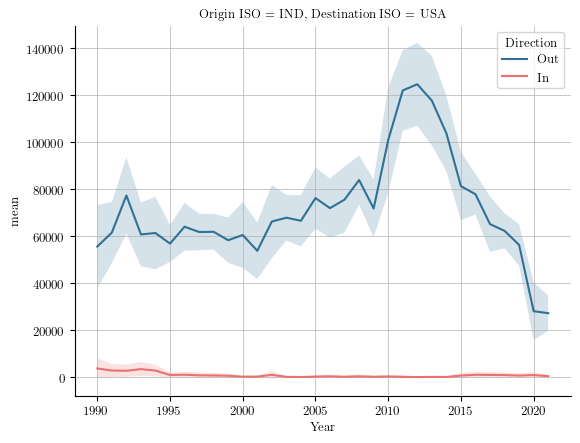

In [5]:
fig, ax = plt.subplots()
org, dest = "IND", "USA"
m = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest})["mean"]
std = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest})["std"]
for dir in ["Out", "In"]:
    ax.fill_between(extended_flow.coords["Year"].data, m.sel({"Direction": dir})-std.sel({"Direction": dir}), m.sel({"Direction": dir})+std.sel({"Direction": dir}), alpha=0.2)
m.plot.line(hue="Direction", ax=ax)

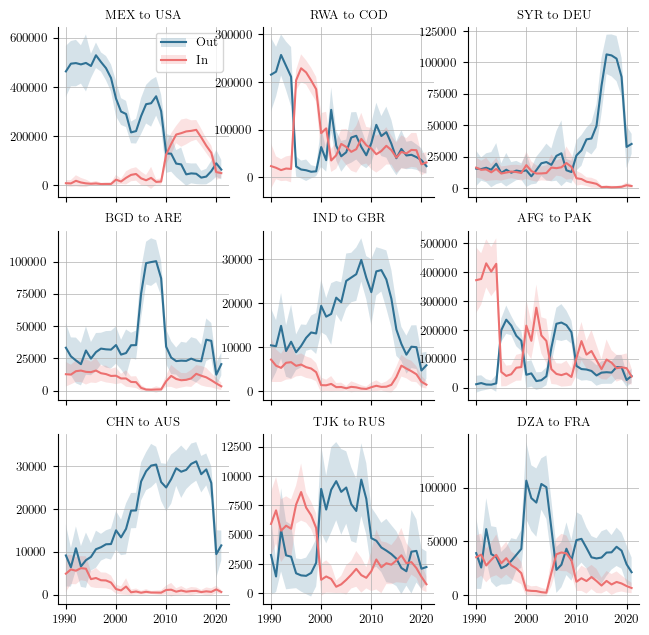

In [6]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["DZA", "FRA"]]
for idx, pair in enumerate(pairs):
    org, dest = pair
    handles = []
    for dir in ["Out", "In"]:
        m = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest, "Direction": dir})["mean"]
        std = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest, "Direction": dir})["std"]
        f = axs.flatten()[idx].fill_between(flow_table.coords["Year"].data, m-std, m+std, alpha=0.2)
        l = m.plot.line(ax=axs.flatten()[idx])
        handles.append((f, l[0]))
    axs.flatten()[idx].set_title(f"{org} to {dest}")
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
axs.flatten()[0].legend(handles=handles, labels=['Out', 'In'])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/extended_flow.pdf", bbox_inches='tight')

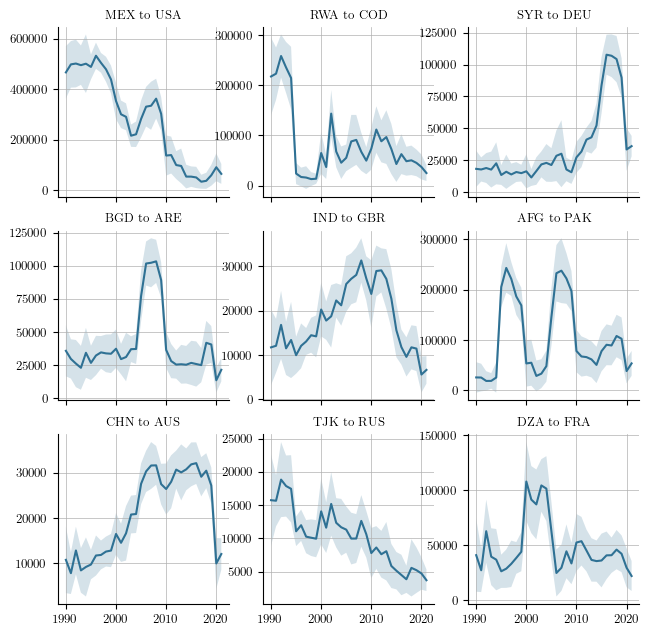

In [7]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["DZA", "FRA"]]
for idx, pair in enumerate(pairs):
    org, dest = pair
    m = flow_table.sel({"Origin ISO": org, "Destination ISO": dest})["mean"]
    std = flow_table.sel({"Origin ISO": org, "Destination ISO": dest})["std"]
    axs.flatten()[idx].fill_between(flow_table.coords["Year"].data, m-std, m+std, alpha=0.2)
    m.plot.line(ax=axs.flatten()[idx])
    axs.flatten()[idx].set_title(f"{org} to {dest}")
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/total_flow.pdf", bbox_inches='tight')

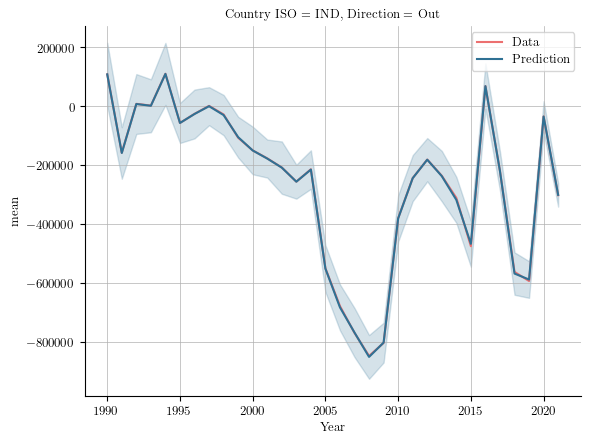

In [8]:
fig, ax = plt.subplots()
c="IND"
UN_net_migration.sel({'Year': predicted_net_migration.coords["Year"].data}).sel({"Country ISO": c}).plot(ax=ax, label="Data", color=colors["c_red"])
ax.fill_between(predicted_net_migration.coords["Year"].data,
                (predicted_net_migration["mean"] - predicted_net_migration["std"]).sel({"Country ISO": c}),
                (predicted_net_migration["mean"] + predicted_net_migration["std"]).sel({"Country ISO": c}), 
                alpha=0.2, color=colors["c_darkblue"])
predicted_net_migration["mean"].sel({"Country ISO": c}).plot(ax=ax, label="Prediction", color=colors["c_darkblue"])
ax.legend()

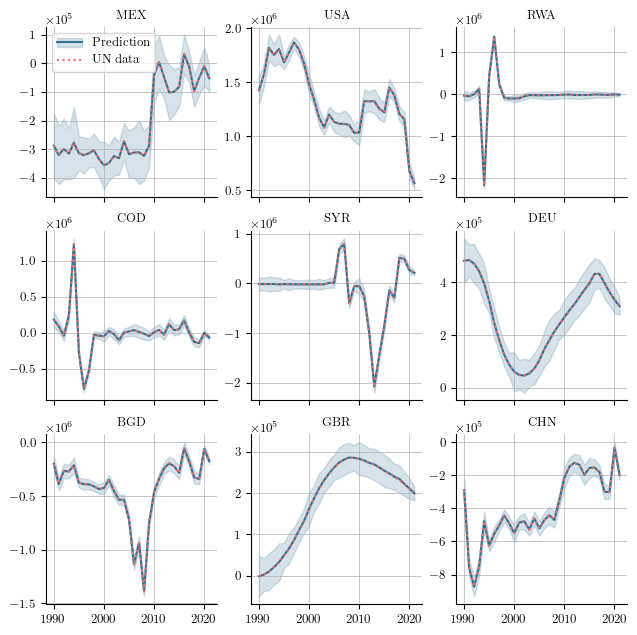

In [9]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, sharey=False, figsize=(7.5, 7.5))
countries = ["MEX", "USA", "RWA", "COD", "SYR", "DEU", "BGD", "GBR", "CHN"]
for idx, c in enumerate(countries):
    f = axs.flatten()[idx].fill_between(predicted_net_migration.coords["Year"].data,
                    (predicted_net_migration["mean"] - predicted_net_migration["std"]).sel({"Country ISO": c}),
                    (predicted_net_migration["mean"] + predicted_net_migration["std"]).sel({"Country ISO": c}), 
                    alpha=0.2, color=colors["c_darkblue"])
    p = predicted_net_migration["mean"].sel({"Country ISO": c}).plot(ax=axs.flatten()[idx], label="Prediction", color=colors["c_darkblue"])
    u = UN_net_migration.sel({'Year': predicted_net_migration.coords["Year"].data}).sel({"Country ISO": c}).plot(ax=axs.flatten()[idx], label="Data", color=colors["c_red"], linestyle='dotted')
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
    axs.flatten()[idx].set_title(f"{c}")
    axs.flatten()[idx].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axs.flatten()[0].legend(handles=[(f, p[0]), u[0]], labels=["Prediction", "UN data"])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/pred_net_migration.pdf")

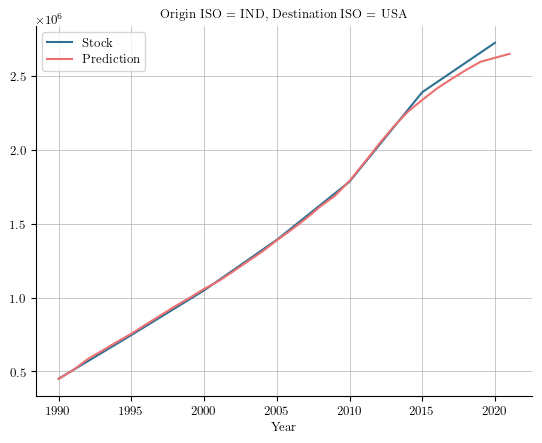

In [10]:
fig, ax = plt.subplots()
org, dest = "IND", "USA"
stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label="Stock")

stock = [stock_data.sel({"Year": 1990, "Origin ISO": org, "Destination ISO": dest}).data]
for y in extended_flow.coords["Year"].data[1:]:
    stock.append(
        stock[-1] + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True) - extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)
    )
ax.plot(extended_flow.coords["Year"].data, stock, label="Prediction")
ax.legend()

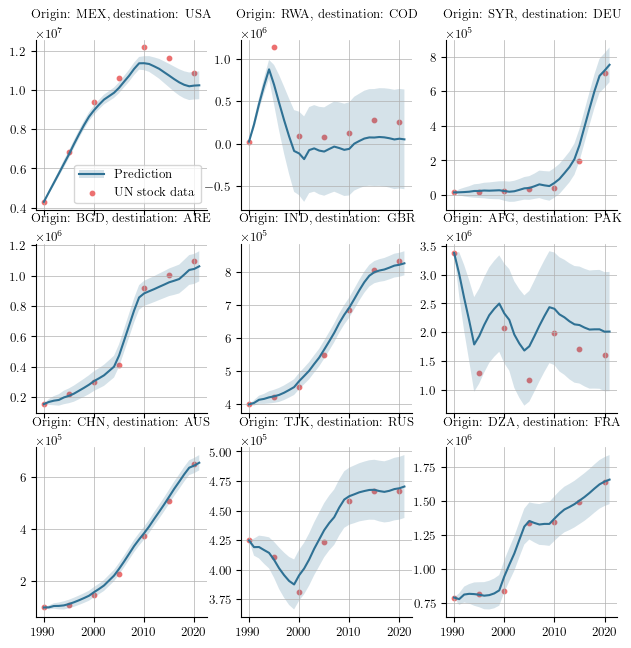

In [11]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["DZA", "FRA"]]
for idx, pair in enumerate(pairs):
    
    org, dest = pair
    s = stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot.scatter(ax=axs.flatten()[idx], color=colors['c_red'], x="Year", s=10)
    
    stock = [stock_data.sel({"Year": 1990, "Origin ISO": org, "Destination ISO": dest}).data]
    uncert = [0]
    for y in extended_flow.coords["Year"].data[1:]:
        stock.append(
            stock[-1] + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True) - extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)
        )
        uncert.append(
            np.sqrt(uncert[-1]**2 + np.sqrt(extended_flow["std"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True)**2 + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)**2)**2)
        )
    u = axs.flatten()[idx].fill_between(extended_flow.coords["Year"].data, np.array(stock) - np.array(uncert), np.array(stock) + np.array(uncert), alpha=0.2)
    p = axs.flatten()[idx].plot(extended_flow.coords["Year"].data, stock)
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
    axs.flatten()[idx].set_title(f"Origin: {org}, destination: {dest}")
    axs.flatten()[idx].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axs.flatten()[0].legend(handles=[(u, p[0]), s], labels=['Prediction', 'UN stock data'])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/pred_stock.pdf")

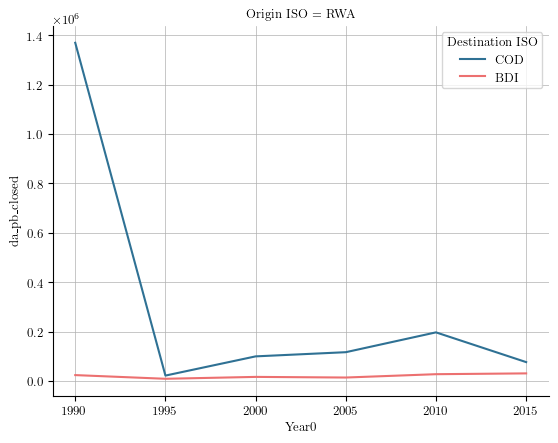

In [26]:
five_year_estimates["da_pb_closed"].sel({"Origin ISO": "RWA", "Destination ISO": ["COD", "BDI"]}).plot(hue="Destination ISO")

In [12]:
pred_five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    pred_five_year_estimates.append(
        flow_table["mean"].sel({"Year": range(y, y+5)}).sum("Year")
    )
pred_five_year_estimates = xr.concat(pred_five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

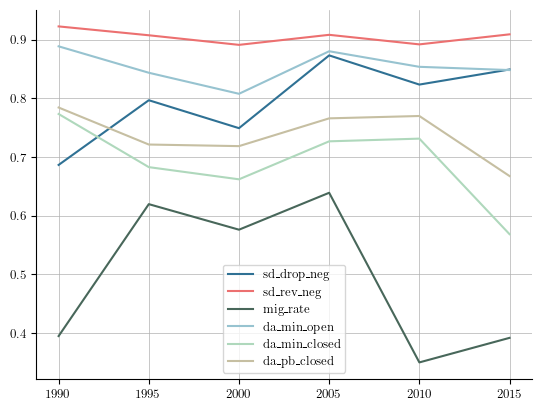

In [13]:
common_countries  = np.intersect1d(five_year_estimates.coords["Origin ISO"], pred_five_year_estimates.coords["Origin ISO"])
fig, ax = plt.subplots()
for var in list(five_year_estimates.data_vars):
    r_coeffs = []
    for year in five_year_estimates.coords["Year0"]:
        x = pred_five_year_estimates.sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        y = five_year_estimates[var].sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        msk = np.where(~np.isnan(y))
        r_coeffs.append(scipy.stats.pearsonr(x[msk], y[msk]).statistic)
    ax.plot(five_year_estimates.coords["Year0"], r_coeffs, label=var)
ax.legend()

In [14]:
bilat = pd.read_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/bilat.csv")

In [15]:
bilat[(bilat.definition == "birth")].collection.unique()

array(['celede', 'demig_c2c', 'oecd', 'un_desa_imfsc'], dtype=object)

In [23]:
bilat['method'].unique()

array(['da_min_open', 'da_min_closed', 'da_pb_closed', 'sd_drop_neg',
       'sd_rev_neg', 'mig_rate'], dtype=object)

In [17]:
bilat[(bilat.collection == "un_desa_imfsc") & (bilat.orig == "ZWE") & (bilat.dest == "USA")]

,collection,orig,dest,year0,rep_flow,rep_tot,est_flow,est_tot,method,coverage,definition,type
2785533,un_desa_imfsc,ZWE,USA,1990,1383.0,6046333.00,7829.00,26326812.92,da_min_open,foreigners,birth,imm
2785534,un_desa_imfsc,ZWE,USA,1990,1383.0,6046333.00,14963.72,27204422.93,da_min_closed,foreigners,birth,imm
2785535,un_desa_imfsc,ZWE,USA,1990,1383.0,6046333.00,14963.72,27204422.84,da_pb_closed,foreigners,birth,imm
2785536,un_desa_imfsc,ZWE,USA,1990,1383.0,6046333.00,7829.00,26326812.92,da_min_open,foreigners,birth,imm
2785537,un_desa_imfsc,ZWE,USA,1990,1383.0,6046333.00,14963.72,27204422.93,da_min_closed,foreigners,birth,imm
...,...,...,...,...,...,...,...,...,...,...,...,...
2785600,un_desa_imfsc,ZWE,USA,2010,5160.0,5158561.25,55354.88,46255766.08,da_min_closed,foreigners,birth,imm
2785601,un_desa_imfsc,ZWE,USA,2010,5160.0,5158561.25,55354.88,46255766.10,da_pb_closed,foreigners,birth,imm
2785602,un_desa_imfsc,ZWE,USA,2010,5160.0,5158561.25,55396.26,45591488.65,da_min_open,foreigners,birth,imm
2785603,un_desa_imfsc,ZWE,USA,2010,5160.0,5158561.25,55354.88,46255766.08,da_min_closed,foreigners,birth,imm


In [20]:
fyest = pred_five_year_estimates.rename({"Origin ISO": "orig", "Destination ISO": "dest", "Year0": "year0"}).to_dataframe().reset_index()
fyest["method"] = "NN"
fyest["collection"] = "un_desa_imfsc"
fyest.rename({"mean": "est_flow"}, axis=1, inplace=True)
fyest["coverage"] = "birth"

In [21]:
fyest

,year0,orig,dest,Direction,est_flow,method,collection,coverage
0,1990,ABW,ABW,Out,228.644716,NN,un_desa_imfsc,birth
1,1990,ABW,AFG,Out,29526.853432,NN,un_desa_imfsc,birth
2,1990,ABW,AGO,Out,13625.577148,NN,un_desa_imfsc,birth
3,1990,ABW,AIA,Out,13287.961170,NN,un_desa_imfsc,birth
4,1990,ABW,ALB,Out,13590.206259,NN,un_desa_imfsc,birth
...,...,...,...,...,...,...,...,...
334171,2015,ZWE,XKX,Out,12470.913673,NN,un_desa_imfsc,birth
334172,2015,ZWE,YEM,Out,13366.894464,NN,un_desa_imfsc,birth
334173,2015,ZWE,ZAF,Out,99685.964438,NN,un_desa_imfsc,birth
334174,2015,ZWE,ZMB,Out,12345.546683,NN,un_desa_imfsc,birth
